In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset

In [35]:
current_path = Path().cwd()
project_dir = current_path.parents[1]
data_path = project_dir / "data" / "data_processed"
file_path = data_path / "cassava" / "price_avg.csv"

wide = pd.read_csv(file_path)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [36]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [37]:
SEQ_LEN = 12
PRED_LEN = 12


class SeqDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        seq = self.data[idx : idx + self.seq_len]
        targ = self.data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.from_numpy(seq).unsqueeze(-1), torch.from_numpy(targ)


In [38]:
ds = SeqDataset(series, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

In [39]:
class LSTMRegressor(nn.Module):
    def __init__(self, hidden=32, layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=layers, batch_first=True
        )
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [40]:
model = LSTMRegressor()
crit = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-2)

EPOCHS = 300
for epoch in range(1, EPOCHS + 1):
    for seq, targ in loader:
        opt.zero_grad()
        pred = model(seq)
        loss = crit(pred.squeeze(), targ[:, 0])
        loss.backward()
        opt.step()
    if epoch % 50 == 0:
        print(f"epoch {epoch:>3}/{EPOCHS}  loss={loss.item():.5f}")

epoch  50/300  loss=0.01270
epoch 100/300  loss=0.00323
epoch 150/300  loss=0.00231
epoch 200/300  loss=0.00149
epoch 250/300  loss=0.00120
epoch 300/300  loss=0.00118


In [41]:
model.eval()
with torch.no_grad():
    window = torch.from_numpy(series[-SEQ_LEN:]).unsqueeze(0).unsqueeze(-1)
    preds = []
    for _ in range(PRED_LEN):
        nxt = model(window)
        preds.append(nxt.item())
        window = torch.cat([window[:, 1:, :], nxt.unsqueeze(0)], dim=1)

preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()

gregorian_year = 2567 - 543
forecast = pd.Series(
    preds,
    index=pd.date_range(f"{gregorian_year}-01-01", periods=12, freq="MS"),
    name="forecast_price",
)

print("--- Forecast for 2567 ---")
print(forecast.round(2))

--- Forecast for 2567 ---
2024-01-01    3.51
2024-02-01    3.31
2024-03-01    3.19
2024-04-01    3.13
2024-05-01    3.08
2024-06-01    3.02
2024-07-01    2.95
2024-08-01    2.89
2024-09-01    2.84
2024-10-01    2.80
2024-11-01    2.75
2024-12-01    2.71
Freq: MS, Name: forecast_price, dtype: float64


In [42]:
cmp = pd.concat([future["price"].rename("actual"), forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            actual  forecast_price
2024-01-01    3.65            3.51
2024-02-01    3.65            3.31
2024-03-01    3.57            3.19
2024-04-01    3.24            3.13
2024-05-01    3.19            3.08
2024-06-01    3.09            3.02
2024-07-01    3.06            2.95
2024-08-01    2.95            2.89
2024-09-01    2.86            2.84
2024-10-01    2.65            2.80
2024-11-01    2.60            2.75
2024-12-01    2.32            2.71


In [43]:
error = cmp["actual"] - cmp["forecast_price"]
abs_error = error.abs()
pct_error = (error / cmp["actual"]) * 100


print("\n--- Monthly Errors ---")
error_df = pd.DataFrame(
    {
        "actual": cmp["actual"],
        "forecast": cmp["forecast_price"],
        "error": error,
        "abs_error": abs_error,
        "pct_error": pct_error,
    }
)
print(error_df.round(4))

average_percent_error = pct_error.mean()
print(f"\n--- Average Percent Error: {average_percent_error:.2f}% ---")


--- Monthly Errors ---
            actual  forecast   error  abs_error  pct_error
2024-01-01    3.65    3.5079  0.1421     0.1421     3.8922
2024-02-01    3.65    3.3100  0.3400     0.3400     9.3142
2024-03-01    3.57    3.1923  0.3777     0.3777    10.5795
2024-04-01    3.24    3.1330  0.1070     0.1070     3.3028
2024-05-01    3.19    3.0799  0.1101     0.1101     3.4507
2024-06-01    3.09    3.0174  0.0726     0.0726     2.3481
2024-07-01    3.06    2.9532  0.1068     0.1068     3.4896
2024-08-01    2.95    2.8945  0.0555     0.0555     1.8814
2024-09-01    2.86    2.8423  0.0177     0.0177     0.6175
2024-10-01    2.65    2.7952 -0.1452     0.1452    -5.4809
2024-11-01    2.60    2.7520 -0.1520     0.1520    -5.8473
2024-12-01    2.32    2.7125 -0.3925     0.3925   -16.9162

--- Average Percent Error: 0.89% ---


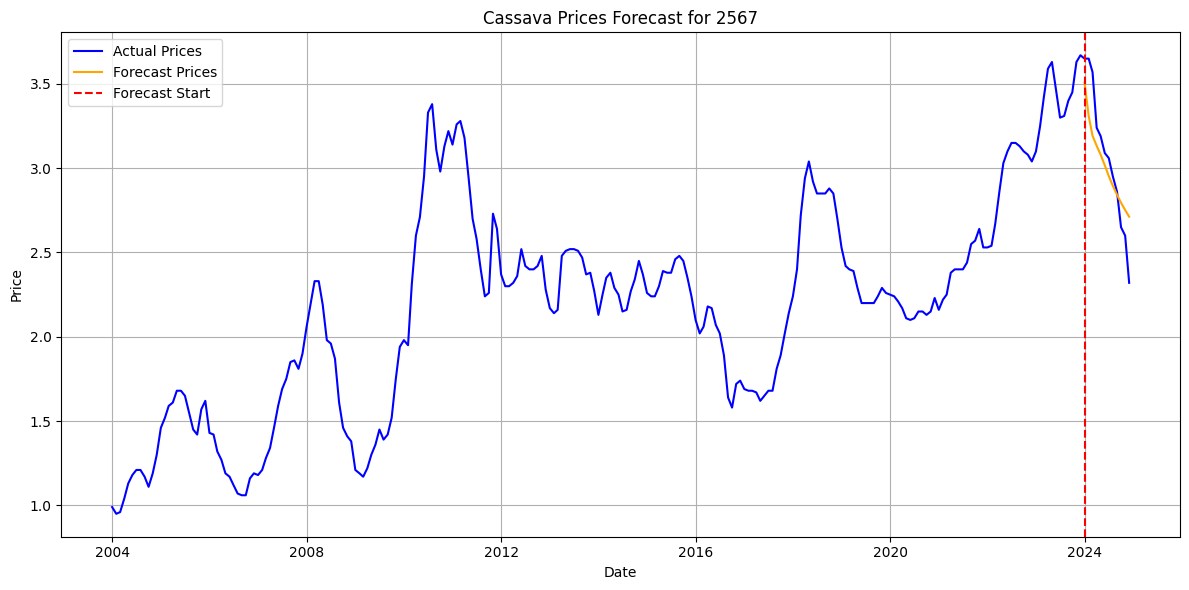

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(forecast.index, forecast, label="Forecast Prices", color="orange")
plt.axvline(
    x=pd.Timestamp(f"{gregorian_year}-01-01"),
    color="red",
    linestyle="--",
    label="Forecast Start",
)
plt.title("Cassava Prices Forecast for 2567")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("cassava_prices_forecast.png")
plt.show()